In [1]:
import os
import sys
sys.path.insert(0, "../..")

import ast
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

from src.constants import C2A_PALETTE, DATA_PATH
plt.rcParams['figure.dpi'] = 300

/home/aliaagheis/miniconda3/envs/fast_env/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1 - Loading and Preprocessing Grounder Results DF

In [66]:
import math
import json

def parse_annotation(df):
    parsed = df['annotation'].apply(ast.literal_eval)
    df['img_filename'] = parsed.apply(lambda x: x['img_filename'])
    df['bbox']         = parsed.apply(lambda x: x['bbox'])        # [x1, y1, x2, y2] absolute pixels
    df['img_size']     = parsed.apply(lambda x: x['img_size'])    # [W, H]
    df['ui_type']      = parsed.apply(lambda x: x['ui_type'])
    df['application']  = parsed.apply(lambda x: x['application'])
    df['platform']     = parsed.apply(lambda x: x['platform'])
    return df

def point_in_bbox(row):
    W, H = row['img_size']                                                                                                                                    
    px = row['coord_x'] * W
    py = row['coord_y'] * H                                                                                                                                   
    x1, y1, x2, y2 = row['bbox']
    return x1 <= px <= x2 and y1 <= py <= y2    

def distance_to_bbox_edge(row):
    "This metric returns 0 if the point is inside the box. If the point is outside, it calculates the shortest Euclidean distance to the nearest edge or corner."
    W, H = row['img_size']
    px = row['coord_x'] * W
    py = row['coord_y'] * H
    x1, y1, x2, y2 = row['bbox']
    # Distance to the horizontal and vertical edges (0 if inside the bounds)
    dx = max(0, x1 - px, px - x2)
    # dy logic uses y1-py and py-y2 assuming y1 < y2 (top-left to bottom-right)
    dy = max(0, y1 - py, py - y2) 
    return math.hypot(dx, dy)

def distance_to_bbox_center(row):
    W, H = row['img_size']
    px = row['coord_x'] * W
    py = row['coord_y'] * H
    x1, y1, x2, y2 = row['bbox']

    # Calculate centroid of the bbox
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    return math.hypot(px - cx, py - cy)

def normalized_distance_to_center(row):
    "We divide the absolute distance in $x$ and $y$ by the width ($w$) and height ($h$) of the bounding box, respectively."
    W, H = row['img_size']
    px = row['coord_x'] * W
    py = row['coord_y'] * H
    x1, y1, x2, y2 = row['bbox']

    # Bbox dimensions
    box_w = x2 - x1
    box_h = y2 - y1
    
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    # Normalize distances by box dimensions
    norm_dx = (px - cx) / box_w
    norm_dy = (py - cy) / box_h

    # Return a scale-invariant distance
    return math.hypot(norm_dx, norm_dy)

In [67]:
results = pd.read_csv("grounder_2.csv", index_col=0)
results = parse_annotation(results)

In [68]:
results_w_prompt = pd.read_csv("grounder_rerun_failed_ones_w_prompt_change.csv", index_col=0)
results_w_prompt = parse_annotation(results_w_prompt)
results_w_prompt = results_w_prompt[~results_w_prompt['coord_x'].isna()]
results_w_prompt = results_w_prompt.drop_duplicates(['img_filename'])

In [69]:
results['coord_x'].isna().sum()

np.int64(32)

In [70]:
# fix coordinates after prompt changes
x_map = results_w_prompt.set_index('img_filename')['coord_x']
y_map = results_w_prompt.set_index('img_filename')['coord_y']

missing_mask = results['coord_x'].isna()

results.loc[missing_mask, 'coord_x'] = results.loc[missing_mask, 'img_filename'].map(x_map)
results.loc[missing_mask, 'coord_y'] = results.loc[missing_mask, 'img_filename'].map(y_map)

In [71]:
results['coord_x'].isna().sum()

np.int64(10)

In [72]:
# results         = results[~results['coord_x'].isna()]
results['hit']                      = results.apply(point_in_bbox, axis=1)
results['dist_to_edge']             = results.apply(distance_to_bbox_edge, axis=1)
results['dist_to_center']           = results.apply(distance_to_bbox_center, axis=1)
results['dist_to_center_norm']      = results.apply(normalized_distance_to_center, axis=1)

results['app/platform'] = results.apply(lambda r: r['application'] + f" ({r['platform']})", axis=1)
results['img_area']     = results.apply(lambda r: r['img_size'][0]*r['img_size'][1], axis=1)
results['bbox_area']    = results.apply(lambda r: (r['bbox'][2] - r['bbox'][0])*(r['bbox'][3] - r['bbox'][1]), axis=1)


In [73]:
results = results[~results['coord_x'].isna()]

In [74]:
results['hit'].value_counts()

hit
False    1240
True      331
Name: count, dtype: int64

In [75]:
results['hit'].value_counts() / len(results)

hit
False    0.789306
True     0.210694
Name: count, dtype: float64

## Visualization

### Utils/Plot/Vis Functions

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle, Circle

DATASET_ROOT = DATA_PATH / "raw" / "screenspot_pro" / "images"

def visualize_row(row, radius=4, bbox_line_width=3, circle_line_width=1.5, fontsize=8, save_file_path = None):
    W, H = row["img_size"]
    px, py = row["coord_x"] * W, row["coord_y"] * H
    bx1, by1, bx2, by2 = row["bbox"]
    img = Image.open(f"{DATASET_ROOT}/{row['img_filename']}")

    fig, ax = plt.subplots(figsize=(14, 14 * H / W))
    ax.imshow(img)
    ax.axis("off")

    # bbox: fill + outline
    ax.add_patch(Rectangle(
        (bx1, by1), bx2 - bx1, by2 - by1,
        facecolor=(*[int(C2A_PALETTE["tertiary"][i:i+2], 16)/255 for i in (1, 3, 5)], 0.2),
        edgecolor=C2A_PALETTE["tertiary"], linewidth=bbox_line_width,
    ))

    # click: big translucent circle + outline
    ax.plot(px, py, "r+", markersize=radius, markeredgewidth=circle_line_width)
    ax.plot(px, py, "o", markersize=radius, markeredgewidth=circle_line_width, markerfacecolor="none", markeredgecolor="red")

    # task: yellow box in top-left with arrow to bbox
    xmid, ymid = (bx1 + bx2)/2, (by1 + by2)/2
    xtext = xmid + 100 if xmid + 100 < W else xmid - 100 
    ytext = ymid - 100 if ymid - 100 > H else ymid + 100 
    ax.annotate(
        f"{row['task']}",
        xy=(xmid, ymid),
        xytext=(xtext, ytext),
        arrowprops=dict(arrowstyle="->", color=C2A_PALETTE["tertiary"]),
        bbox=dict(boxstyle="round,pad=0.3", facecolor=C2A_PALETTE["tertiary"], alpha=0.7),
        fontsize=fontsize,
    )


    plt.tight_layout()
    if save_file_path:
        plt.savefig(f"./results/samples/{save_file_path}")
    else:
        plt.show()


### Visualize ScreenSpot-Pro dataset

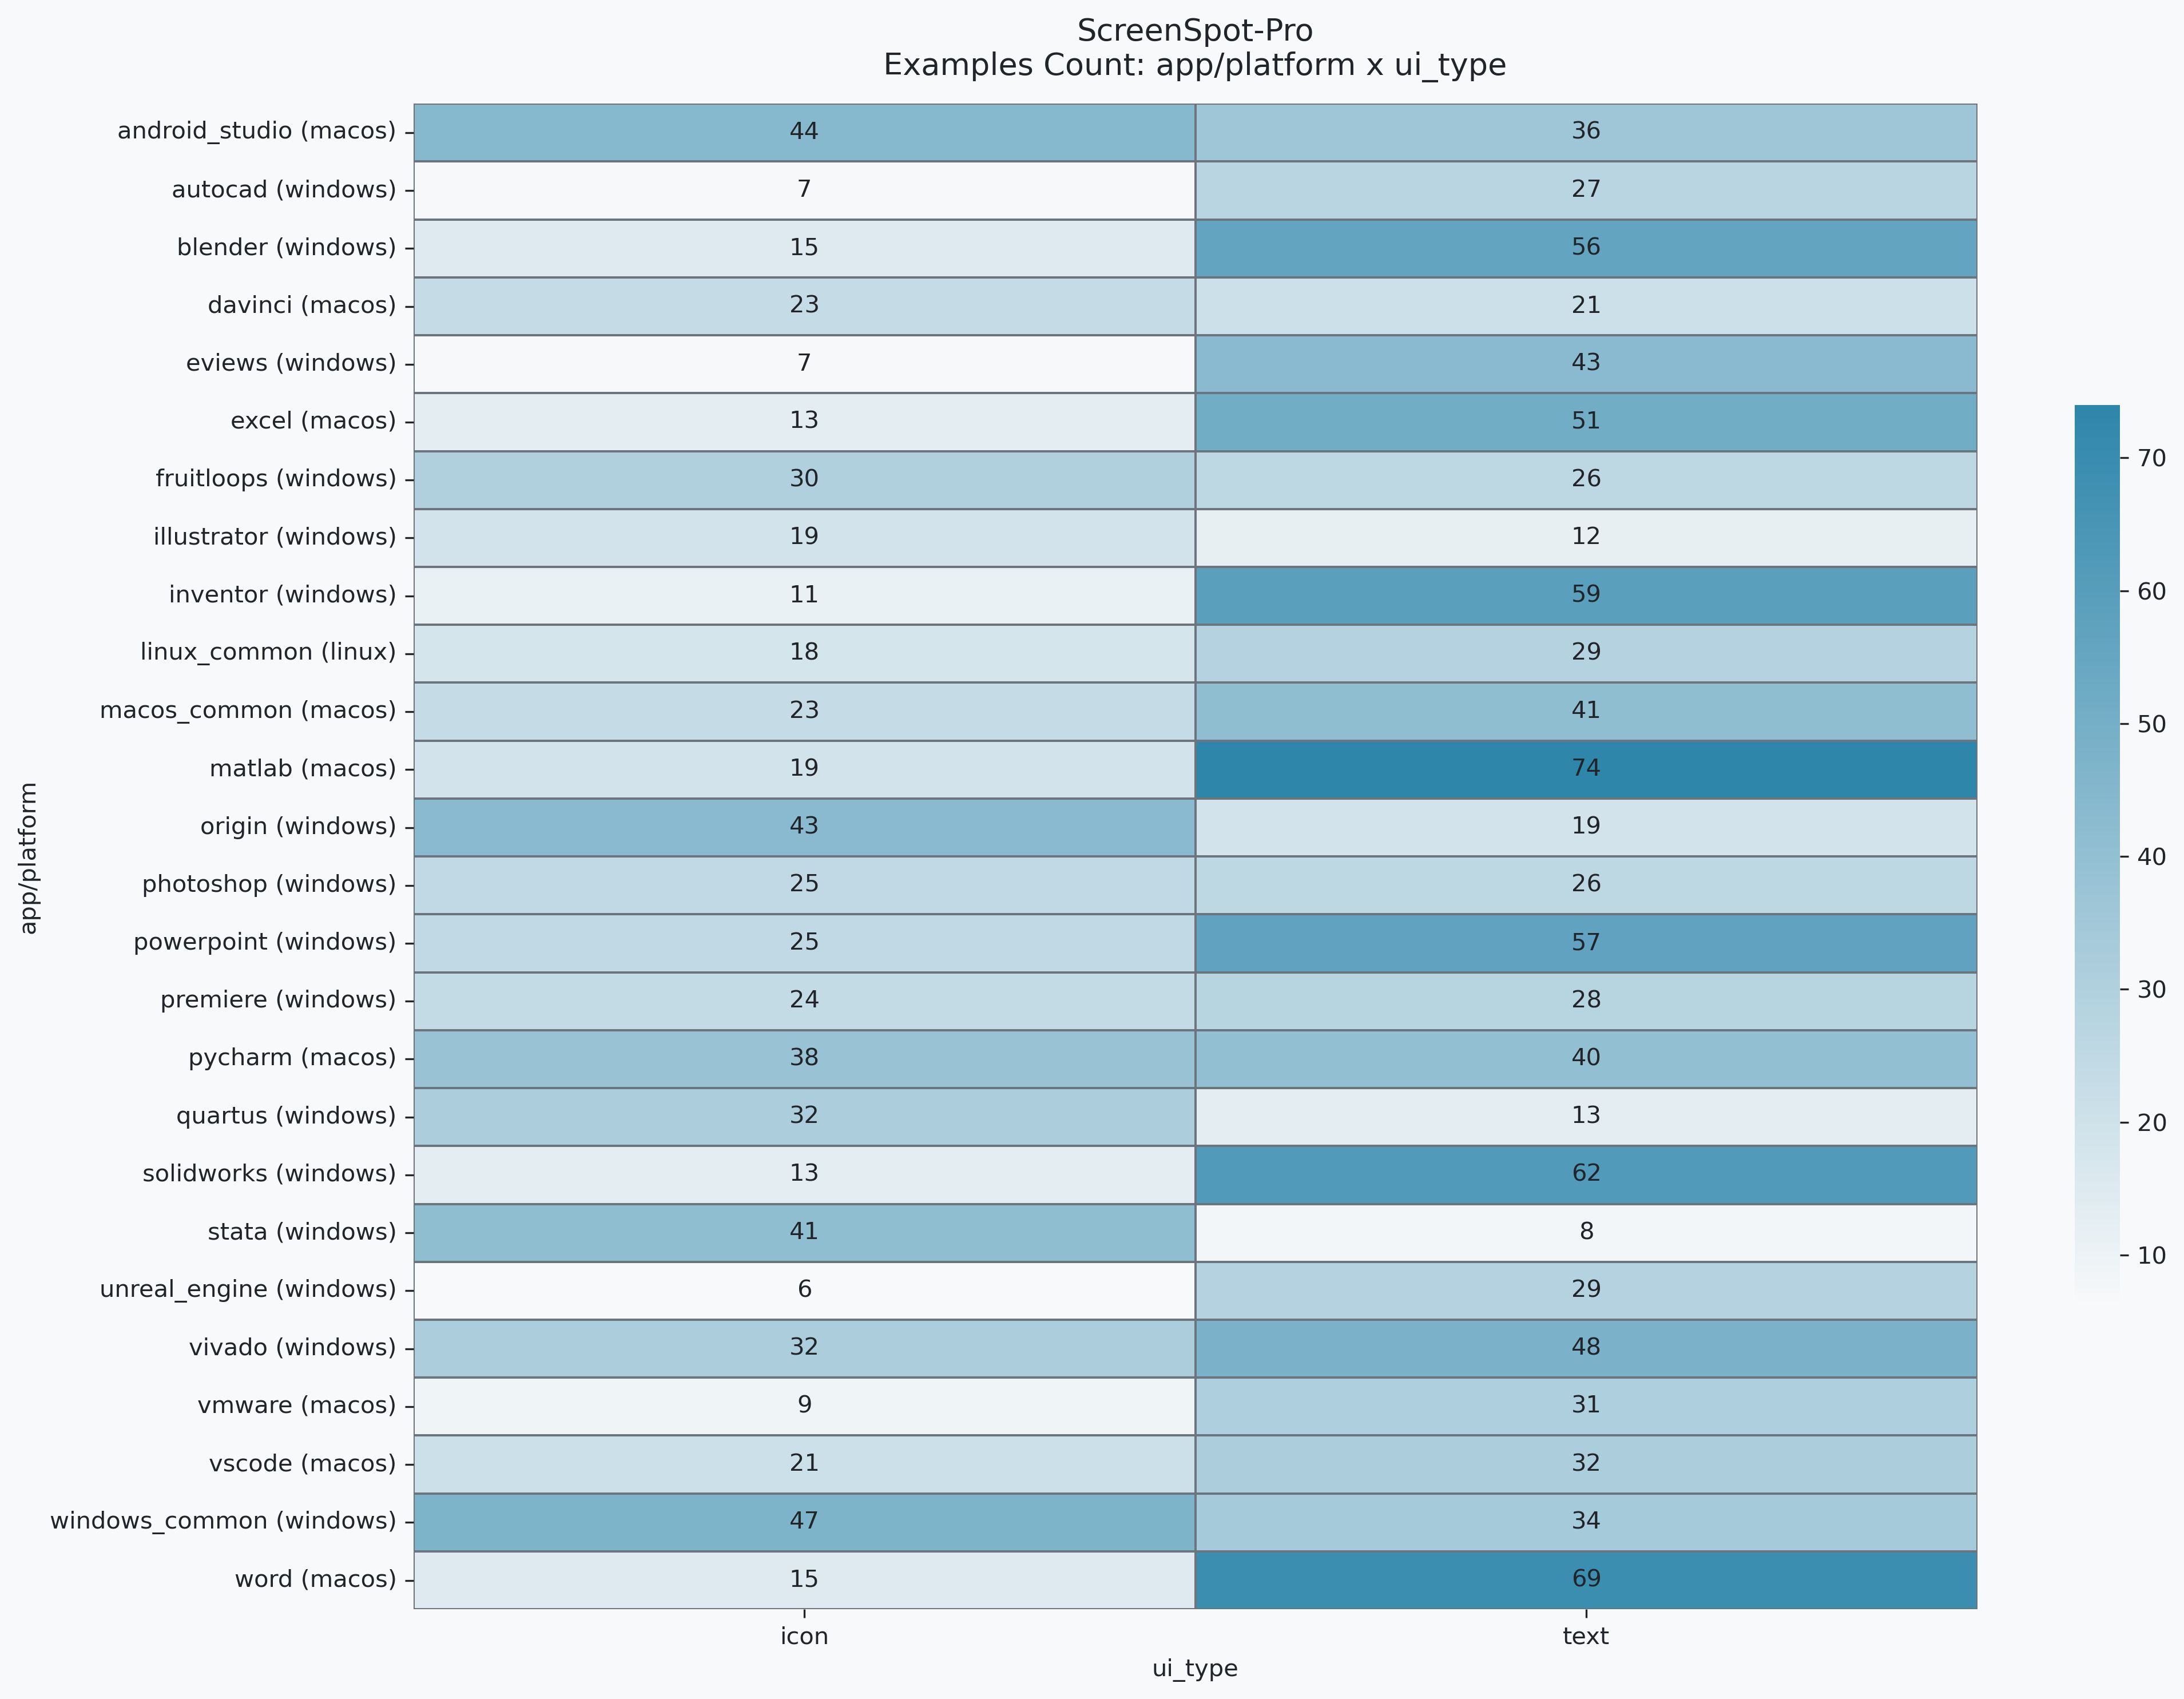

In [77]:

def plot_screenspot_pro_dist(df, figsize=(14, 10)):
    pivot = df.groupby(['app/platform', 'ui_type']).size().unstack(fill_value=0)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "c2a", [C2A_PALETTE["bg"], C2A_PALETTE["primary"]]
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap=cmap,
        linewidths=0.5,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 10},
        cbar_kws={"shrink": 0.6},
    )

    ax.set_title("ScreenSpot-Pro\nExamples Count: app/platform x ui_type", color=C2A_PALETTE["text"], fontsize=13, pad=12)
    ax.set_xlabel("ui_type", color=C2A_PALETTE["text"])
    ax.set_ylabel("app/platform", color=C2A_PALETTE["text"])
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.xaxis.label.set_color(C2A_PALETTE["text"])
    ax.yaxis.label.set_color(C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"])
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.collections[0].colorbar.ax.tick_params(colors=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/screenspot-pro-examples-counts.png")
    plt.show()

plot_screenspot_pro_dist(results)

### Init Visualization of Failed Examples

In [78]:
# from tqdm.auto import tqdm
# for row in tqdm(results[~results['hit']].sample(frac=1).iterrows()):
#     visualize_row(row[1], radius=8, save_file_path=f"failed_{row[0]}.png")

In [79]:
results['hit'].mean()

np.float64(0.21069382558879696)

In [80]:
print((results.groupby('app/platform')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| app/platform             |      hit |
|:-------------------------|---------:|
| eviews (windows)         | 70       |
| word (macos)             | 48.8095  |
| matlab (macos)           | 40.8602  |
| vmware (macos)           | 35       |
| blender (windows)        | 28.169   |
| vivado (windows)         | 27.5     |
| unreal_engine (windows)  | 25.7143  |
| powerpoint (windows)     | 25.6098  |
| photoshop (windows)      | 25.4902  |
| linux_common (linux)     | 23.4043  |
| macos_common (macos)     | 20.3125  |
| premiere (windows)       | 19.2308  |
| vscode (macos)           | 18.8679  |
| fruitloops (windows)     | 17.8571  |
| quartus (windows)        | 15.5556  |
| excel (macos)            | 12.5     |
| pycharm (macos)          | 11.5385  |
| windows_common (windows) | 11.1111  |
| stata (windows)          | 10.2041  |
| origin (windows)         |  9.67742 |
| davinci (macos)          |  9.09091 |
| autocad (windows)        |  8.82353 |
| inventor (windows)       |  7.14286 |


In [81]:
print((results.groupby('ui_type')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| ui_type   |      hit |
|:----------|---------:|
| text      | 31.7199  |
| icon      |  3.83333 |


In [82]:
print((results.groupby('platform')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| platform   |     hit |
|:-----------|--------:|
| linux      | 23.4043 |
| macos      | 23.1667 |
| windows    | 19.5887 |


In [83]:
print(results[~results['hit']]['dist_to_edge'].describe().to_markdown())

|       |   dist_to_edge |
|:------|---------------:|
| count |      1240      |
| mean  |       655.878  |
| std   |       815.087  |
| min   |         0.24   |
| 25%   |        73.3023 |
| 50%   |       248.279  |
| 75%   |      1041.44   |
| max   |      4886.73   |


In [84]:
print(results[~results['hit']]['dist_to_center'].describe().to_markdown())

|       |   dist_to_center |
|:------|-----------------:|
| count |       1240       |
| mean  |        687.758   |
| std   |        815.428   |
| min   |          8.87119 |
| 25%   |        106.788   |
| 50%   |        274.618   |
| 75%   |       1070.8     |
| max   |       4920.4     |


In [85]:
print(results[~results['hit']]['dist_to_center_norm'].describe().to_markdown())

|       |   dist_to_center_norm |
|:------|----------------------:|
| count |           1240        |
| mean  |             22.3184   |
| std   |             30.4832   |
| min   |              0.522438 |
| 25%   |              2.51029  |
| 50%   |              8.56868  |
| 75%   |             30.6922   |
| max   |            272.647    |


In [86]:
results.groupby('ui_type')['hit'].mean().sort_values()[::-1]

ui_type
text    0.317199
icon    0.038333
Name: hit, dtype: float64

In [87]:
results.groupby('platform')['hit'].mean().sort_values()[::-1]

platform
linux      0.234043
macos      0.231667
windows    0.195887
Name: hit, dtype: float64

In [88]:
# results.apply(lambda r: print(r))

In [89]:
results.groupby('app/platform')['hit'].mean().sort_values()[::-1]

app/platform
eviews (windows)            0.700000
word (macos)                0.488095
matlab (macos)              0.408602
vmware (macos)              0.350000
blender (windows)           0.281690
vivado (windows)            0.275000
unreal_engine (windows)     0.257143
powerpoint (windows)        0.256098
photoshop (windows)         0.254902
linux_common (linux)        0.234043
macos_common (macos)        0.203125
premiere (windows)          0.192308
vscode (macos)              0.188679
fruitloops (windows)        0.178571
quartus (windows)           0.155556
excel (macos)               0.125000
pycharm (macos)             0.115385
windows_common (windows)    0.111111
stata (windows)             0.102041
origin (windows)            0.096774
davinci (macos)             0.090909
autocad (windows)           0.088235
inventor (windows)          0.071429
illustrator (windows)       0.064516
solidworks (windows)        0.053333
android_studio (macos)      0.025000
Name: hit, dtype: float64

In [90]:
results.groupby('img_area')['hit'].mean().sort_values()[::-1]

img_area
4096000     0.428571
3110400     0.404040
3686400     0.311891
5184000     0.256098
5595040     0.250000
7464960     0.234043
7720704     0.201258
4259840     0.195652
7372800     0.131148
14745600    0.128571
8294400     0.085185
4147200     0.067039
2073600     0.052632
20358144    0.000000
Name: hit, dtype: float64

### Visualization of Hit Patterns

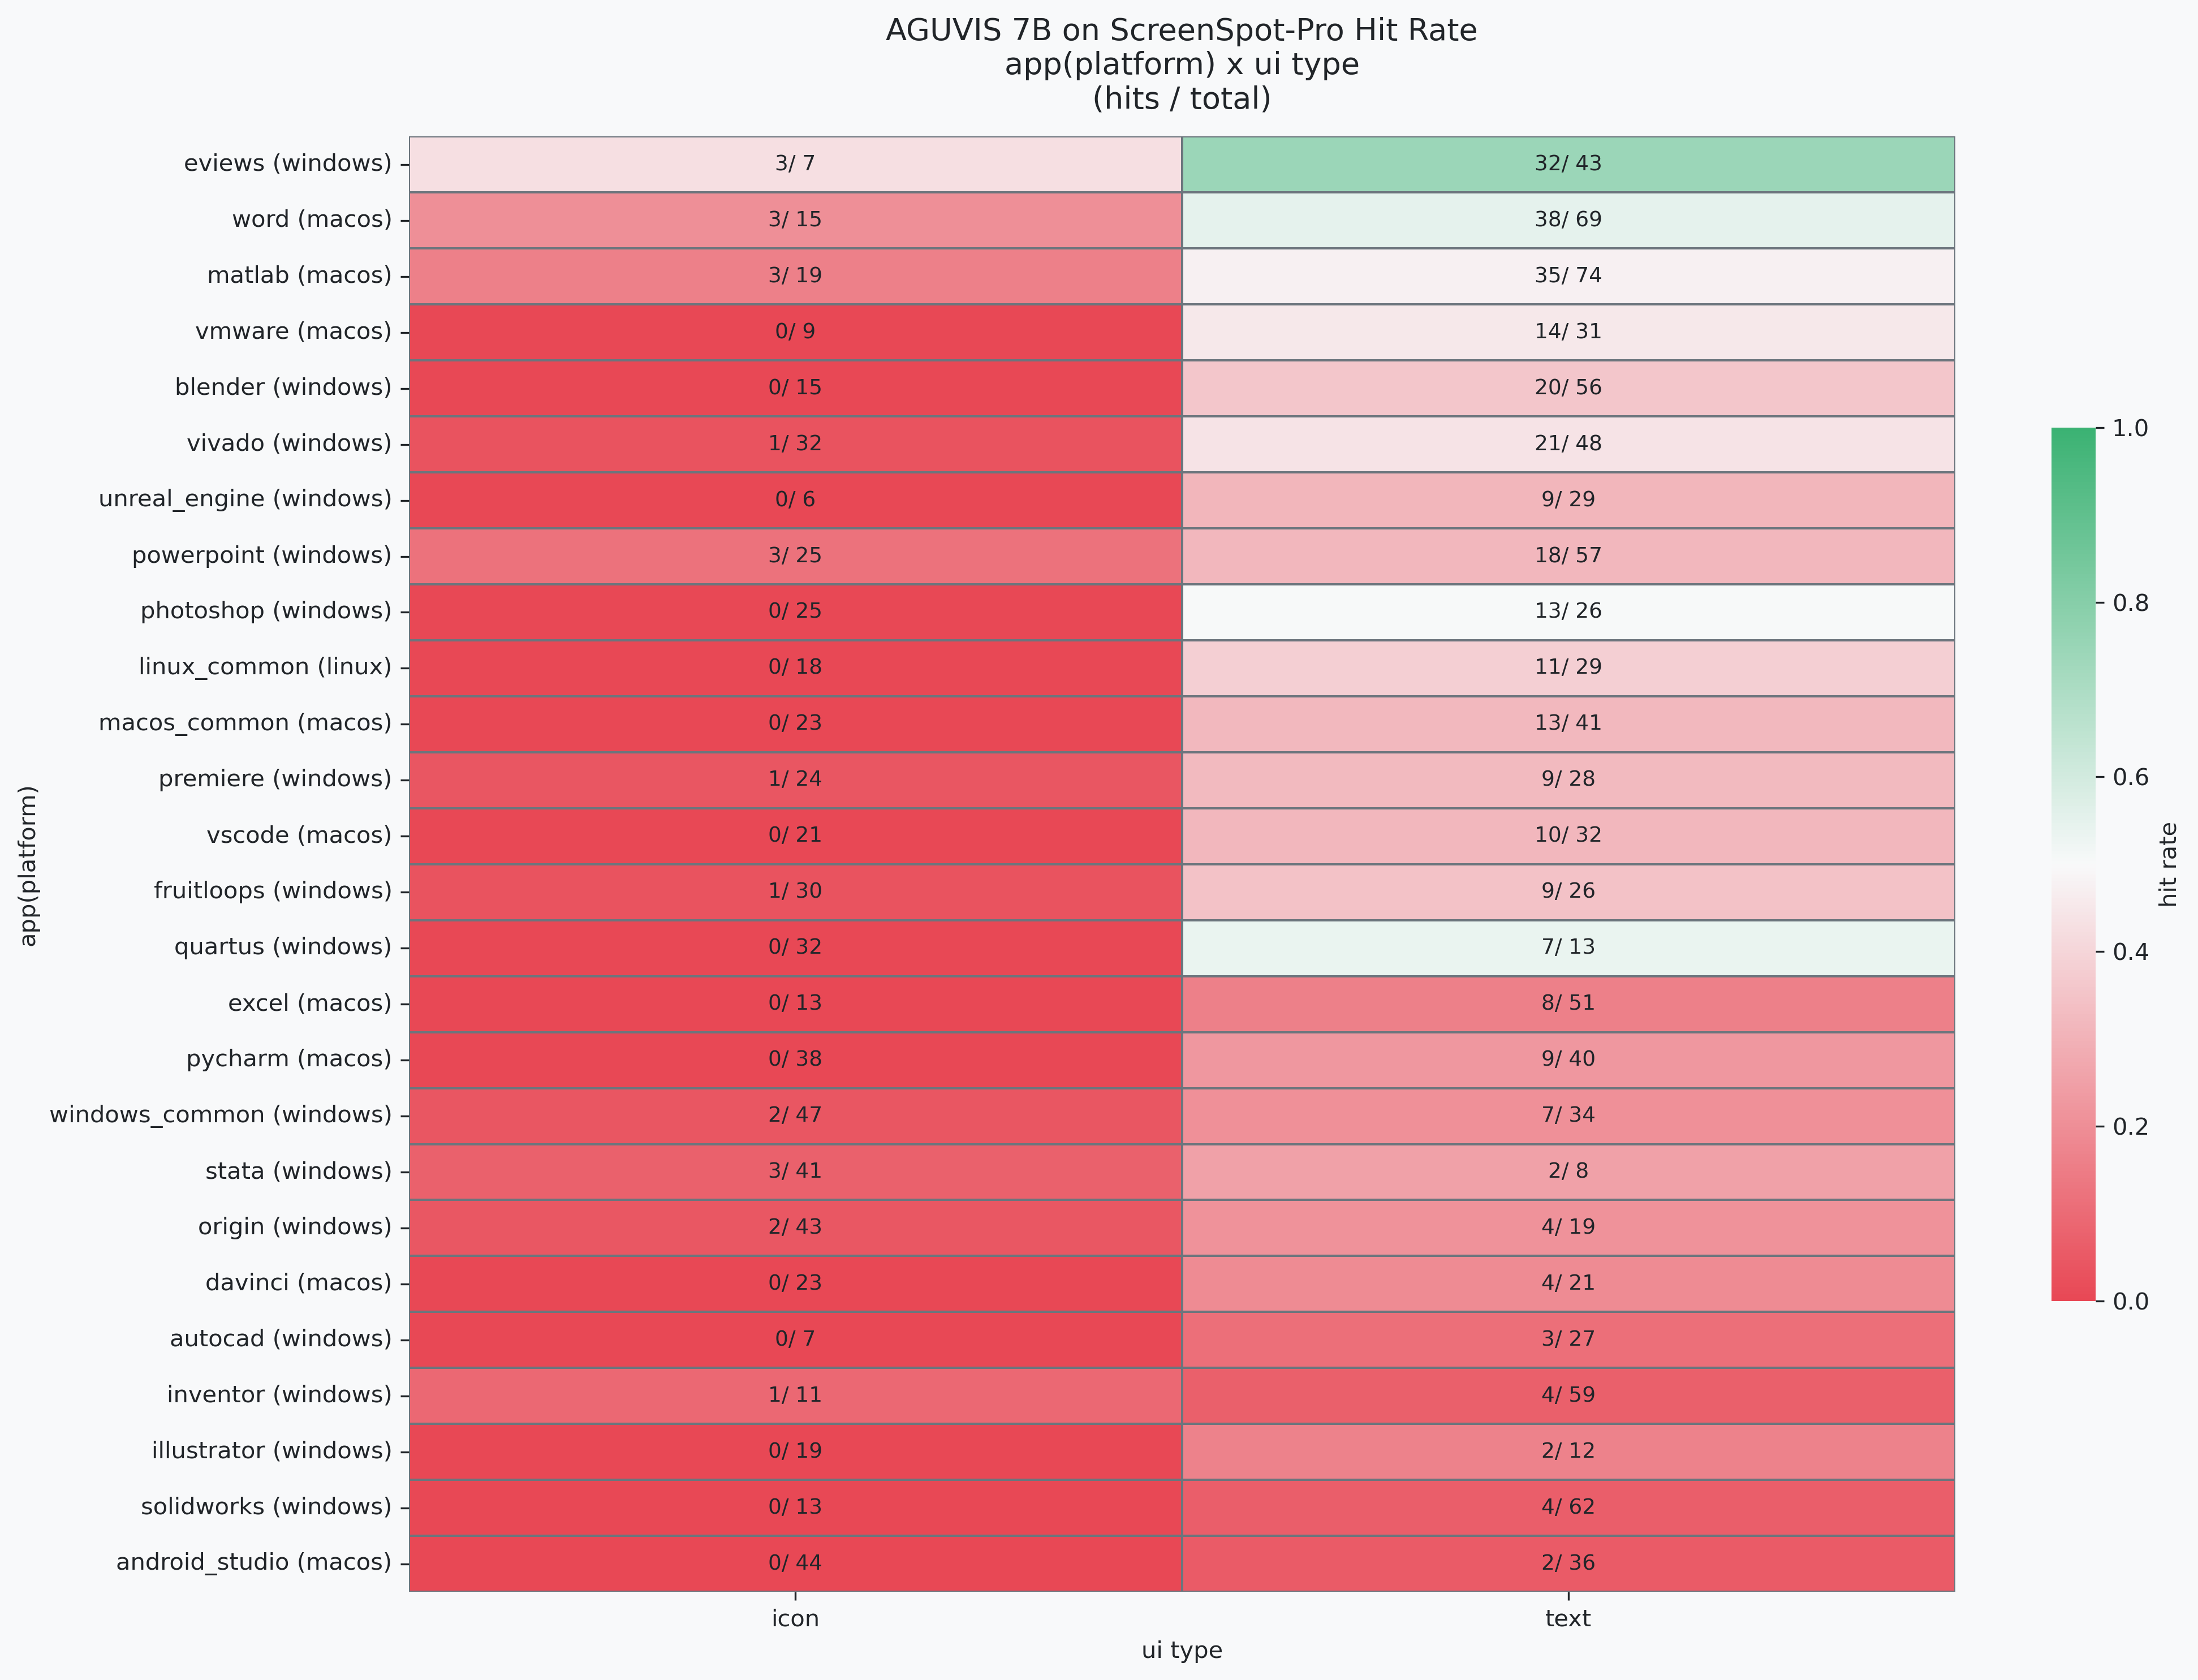

In [91]:

def plot_hit_heatmap(df, figsize=(14, 10)):
    order = df.groupby('app/platform')['hit'].mean().sort_values(ascending=False).index

    grp    = df.groupby(['app/platform', 'ui_type'])['hit']
    hits   = grp.sum().unstack(fill_value=0)
    totals = grp.count().unstack(fill_value=0)
    rates  = (hits / totals.replace(0, float('nan'))).fillna(0)

    # 2. Reorder the rows of all dataframes based on the calculated order
    hits   = hits.reindex(order)
    totals = totals.reindex(order)
    rates  = rates.reindex(order)


    # annotation: "hits/total"
    annot = hits.astype(int).astype(str) + "/ " + totals.astype(int).astype(str)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "c2a_hit", [C2A_PALETTE["warning"], C2A_PALETTE["bg"], C2A_PALETTE["success"]]
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    sns.heatmap(
        rates,
        annot=annot,
        fmt="",
        cmap=cmap,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 9},
        cbar_kws={"shrink": 0.6, "label": "hit rate"},
    )

    ax.set_title("AGUVIS 7B on ScreenSpot-Pro Hit Rate\napp(platform) x ui type\n(hits / total)", color=C2A_PALETTE["text"], fontsize=13, pad=12)
    ax.set_xlabel("ui type", color=C2A_PALETTE["text"])
    ax.set_ylabel("app(platform)", color=C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"])
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.tick_params(colors=C2A_PALETTE["text"])
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors=C2A_PALETTE["text"])
    cbar.ax.yaxis.label.set_color(C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/aguvis-screenspot-pro-examples-hit-rate-counts.png")
    plt.show()

plot_hit_heatmap(results)

In [92]:
# results[(results['application'] == 'word') & (results['ui_type'] == 'icon') & (results['hit'] == False)]

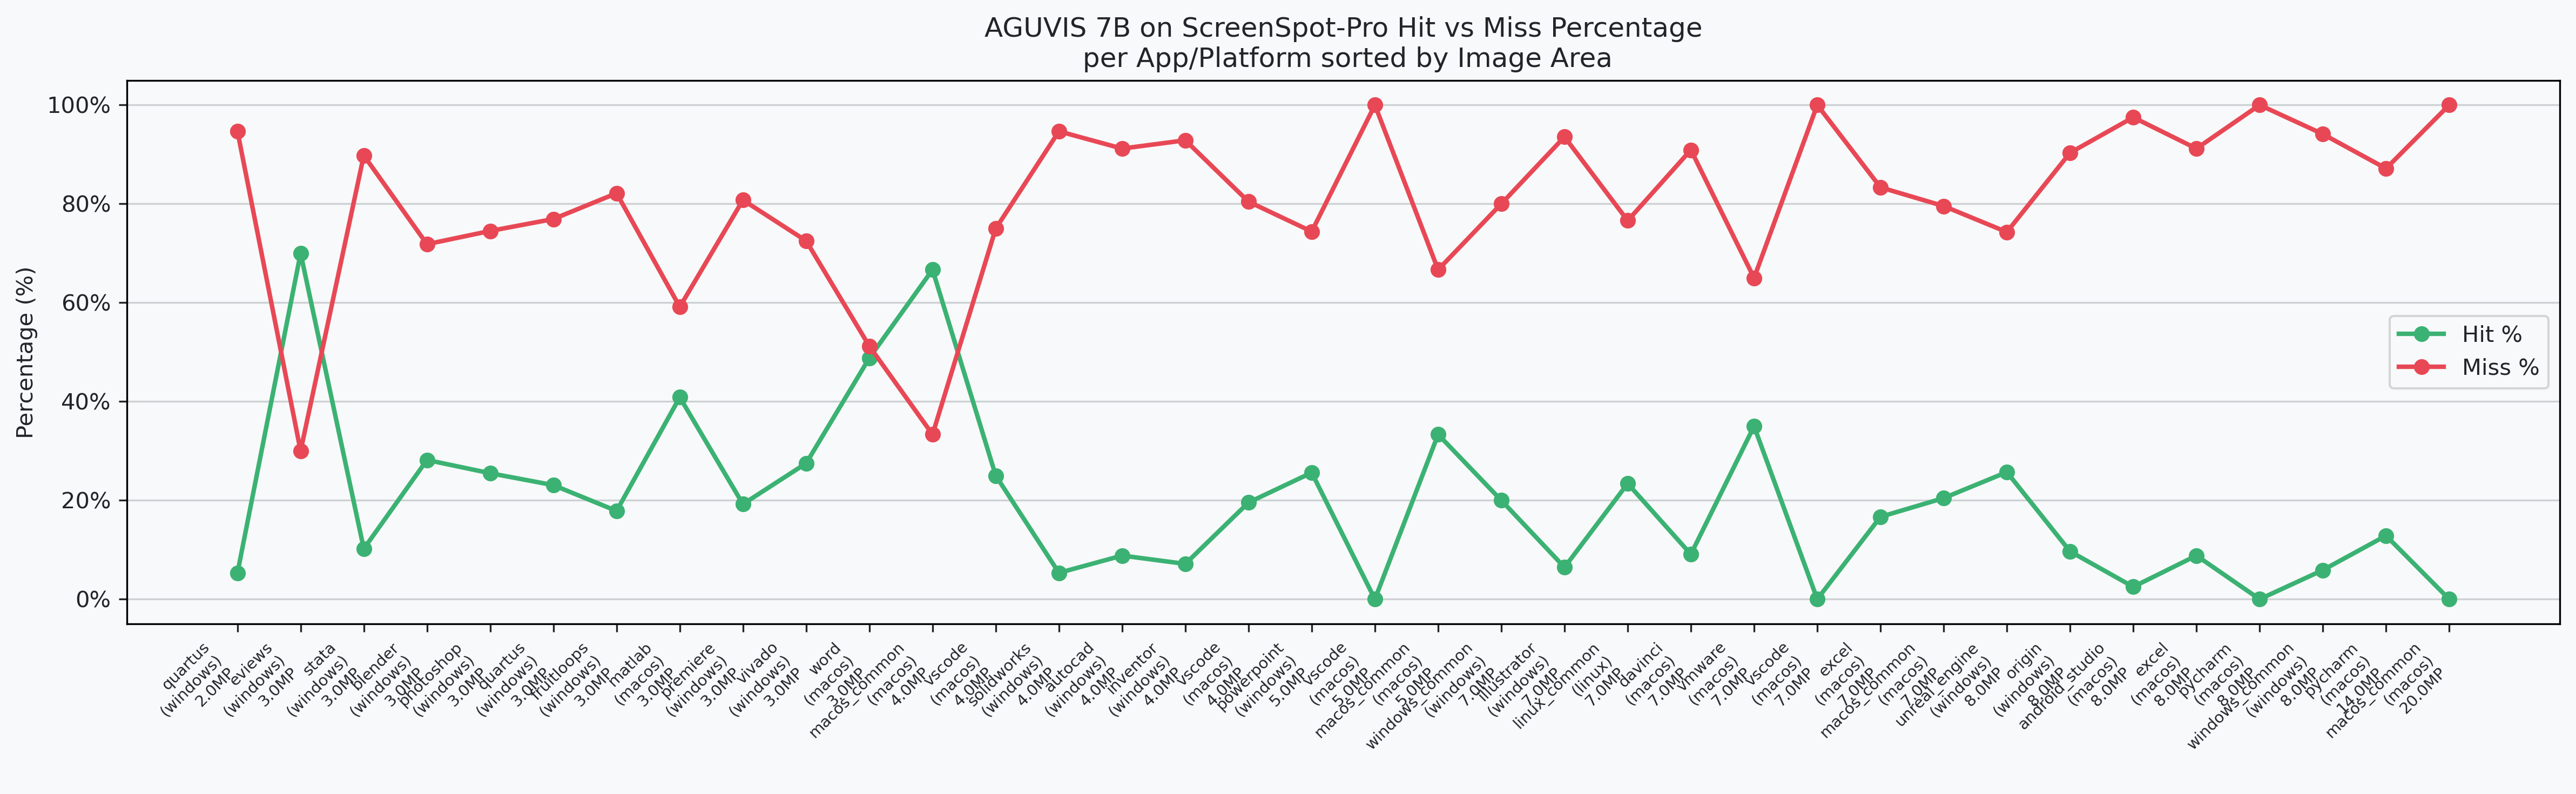

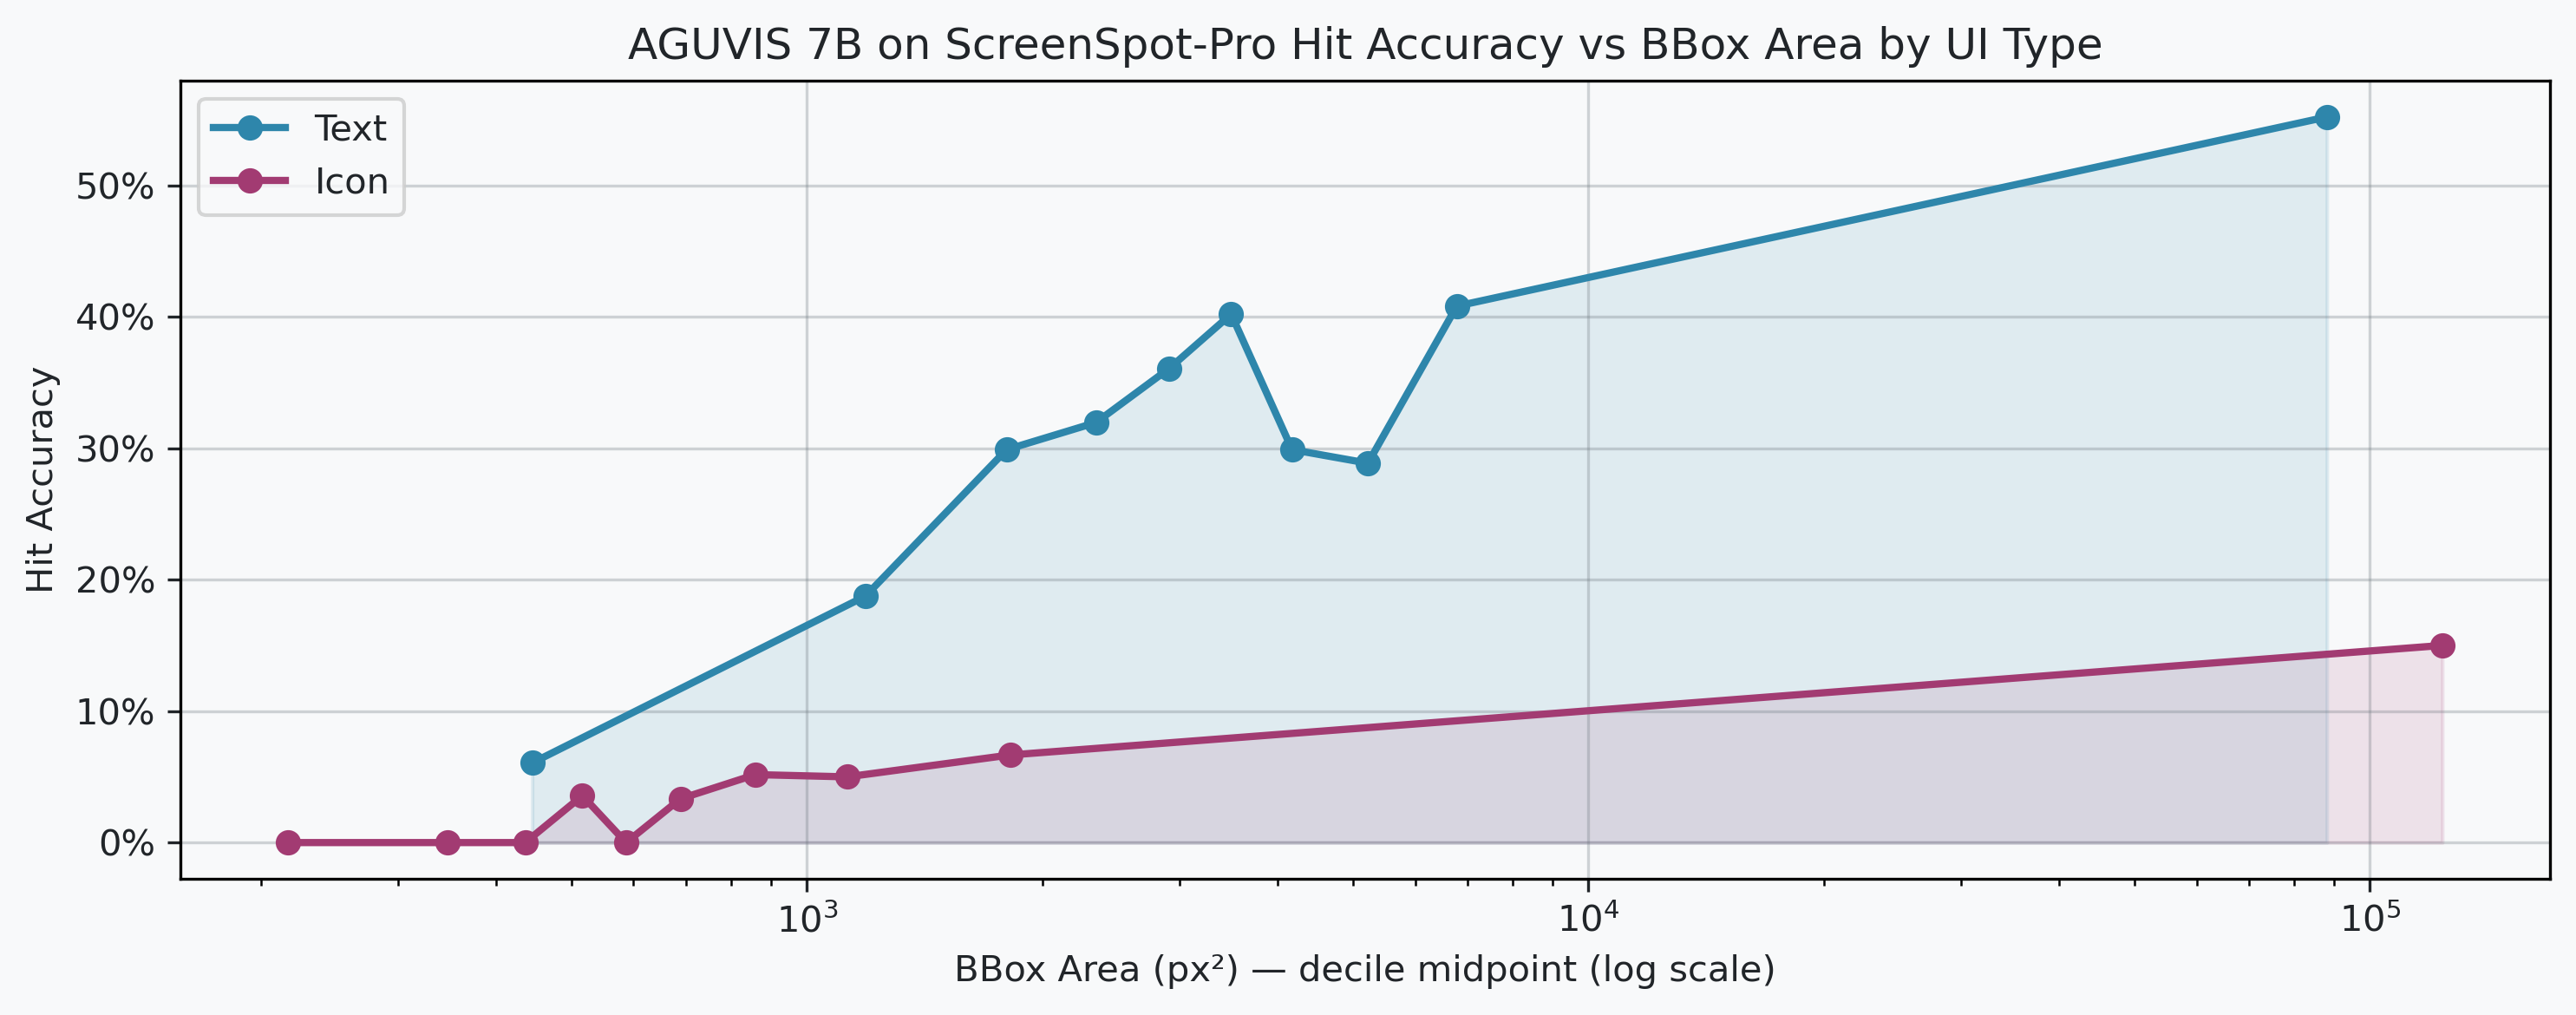

In [93]:
def plot_hit_miss_pct_by_img_area(df):
    # Group and aggregate properly to get raw counts first
    grp = df.groupby(['application', 'platform', 'img_area'])['hit']
    summary = grp.agg(hit='sum', total='count').reset_index()
    summary['miss'] = summary['total'] - summary['hit']
    
    # --- Calculate Percentages ---
    summary['hit_pct'] = (summary['hit'] / summary['total']) * 100
    summary['miss_pct'] = (summary['miss'] / summary['total']) * 100
    
    summary = summary.sort_values('img_area')
    summary['label'] = summary.apply(
        lambda r: f"{r['application']}\n({r['platform']})\n{r['img_area']//1_000_000:.1f}MP", axis=1
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])
    x = range(len(summary))
    
    # --- Plot the percentage columns instead of raw counts ---
    ax.plot(x, summary['hit_pct'],  marker='o', color=C2A_PALETTE["success"], label='Hit %',  linewidth=2)
    ax.plot(x, summary['miss_pct'], marker='o', color=C2A_PALETTE["warning"], label='Miss %', linewidth=2)
    
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary['label'], fontsize=7, color=C2A_PALETTE["text"], rotation=45, ha='right')
    
    # --- Update Labels and Y-axis Formatting ---
    ax.set_ylabel("Percentage (%)", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B on ScreenSpot-Pro Hit vs Miss Percentage\n per App/Platform sorted by Image Area", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    
    # Set y-axis from 0 to 100 and add % formatting
    ax.set_ylim(-5, 105) # Added slight padding so dots don't clip at exactly 0 or 100
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("./results/aguvis-screenspot-pro-hit-miss-perct-per-app-img-area.png")
    plt.show()

def plot_accuracy_by_bbox_area(df, n_bins=10):
    ui_styles = {
        "text": {"color": C2A_PALETTE["primary"],   "label": "Text"},
        "icon": {"color": C2A_PALETTE["secondary"],  "label": "Icon"},
    }

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, style in ui_styles.items():
        subset = df[df['ui_type'] == ui_type].copy()
        subset['bbox_area_bin'] = pd.qcut(subset['bbox_area'], q=n_bins, duplicates='drop')
        bin_acc = subset.groupby('bbox_area_bin', observed=True)['hit'].mean().reset_index()
        bin_acc['bin_mid'] = bin_acc['bbox_area_bin'].apply(lambda b: int(b.mid))

        ax.plot(
            bin_acc['bin_mid'], bin_acc['hit'],
            marker='o', color=style["color"], linewidth=2, label=style["label"]
        )
        ax.fill_between(bin_acc['bin_mid'], bin_acc['hit'], alpha=0.12, color=style["color"])

    ax.set_xscale('log')
    ax.set_xlabel("BBox Area (px²) — decile midpoint (log scale)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Hit Accuracy", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B on ScreenSpot-Pro Hit Accuracy vs BBox Area by UI Type", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/aguvis-screenspot-pro-hit-acc-vs-bbox-area.png")
    plt.show()



plot_hit_miss_pct_by_img_area(results)
plot_accuracy_by_bbox_area(results, 10)

In [94]:
pd.qcut(results['bbox_area'], q=10, duplicates='drop').value_counts().sort_index()

bbox_area
(63.999, 400.0]       158
(400.0, 560.0]        157
(560.0, 810.0]        158
(810.0, 1288.0]       156
(1288.0, 1925.0]      157
(1925.0, 2700.0]      159
(2700.0, 3531.0]      155
(3531.0, 4560.0]      157
(4560.0, 6624.0]      157
(6624.0, 245140.0]    157
Name: count, dtype: int64

### Visualize Distance to BBox

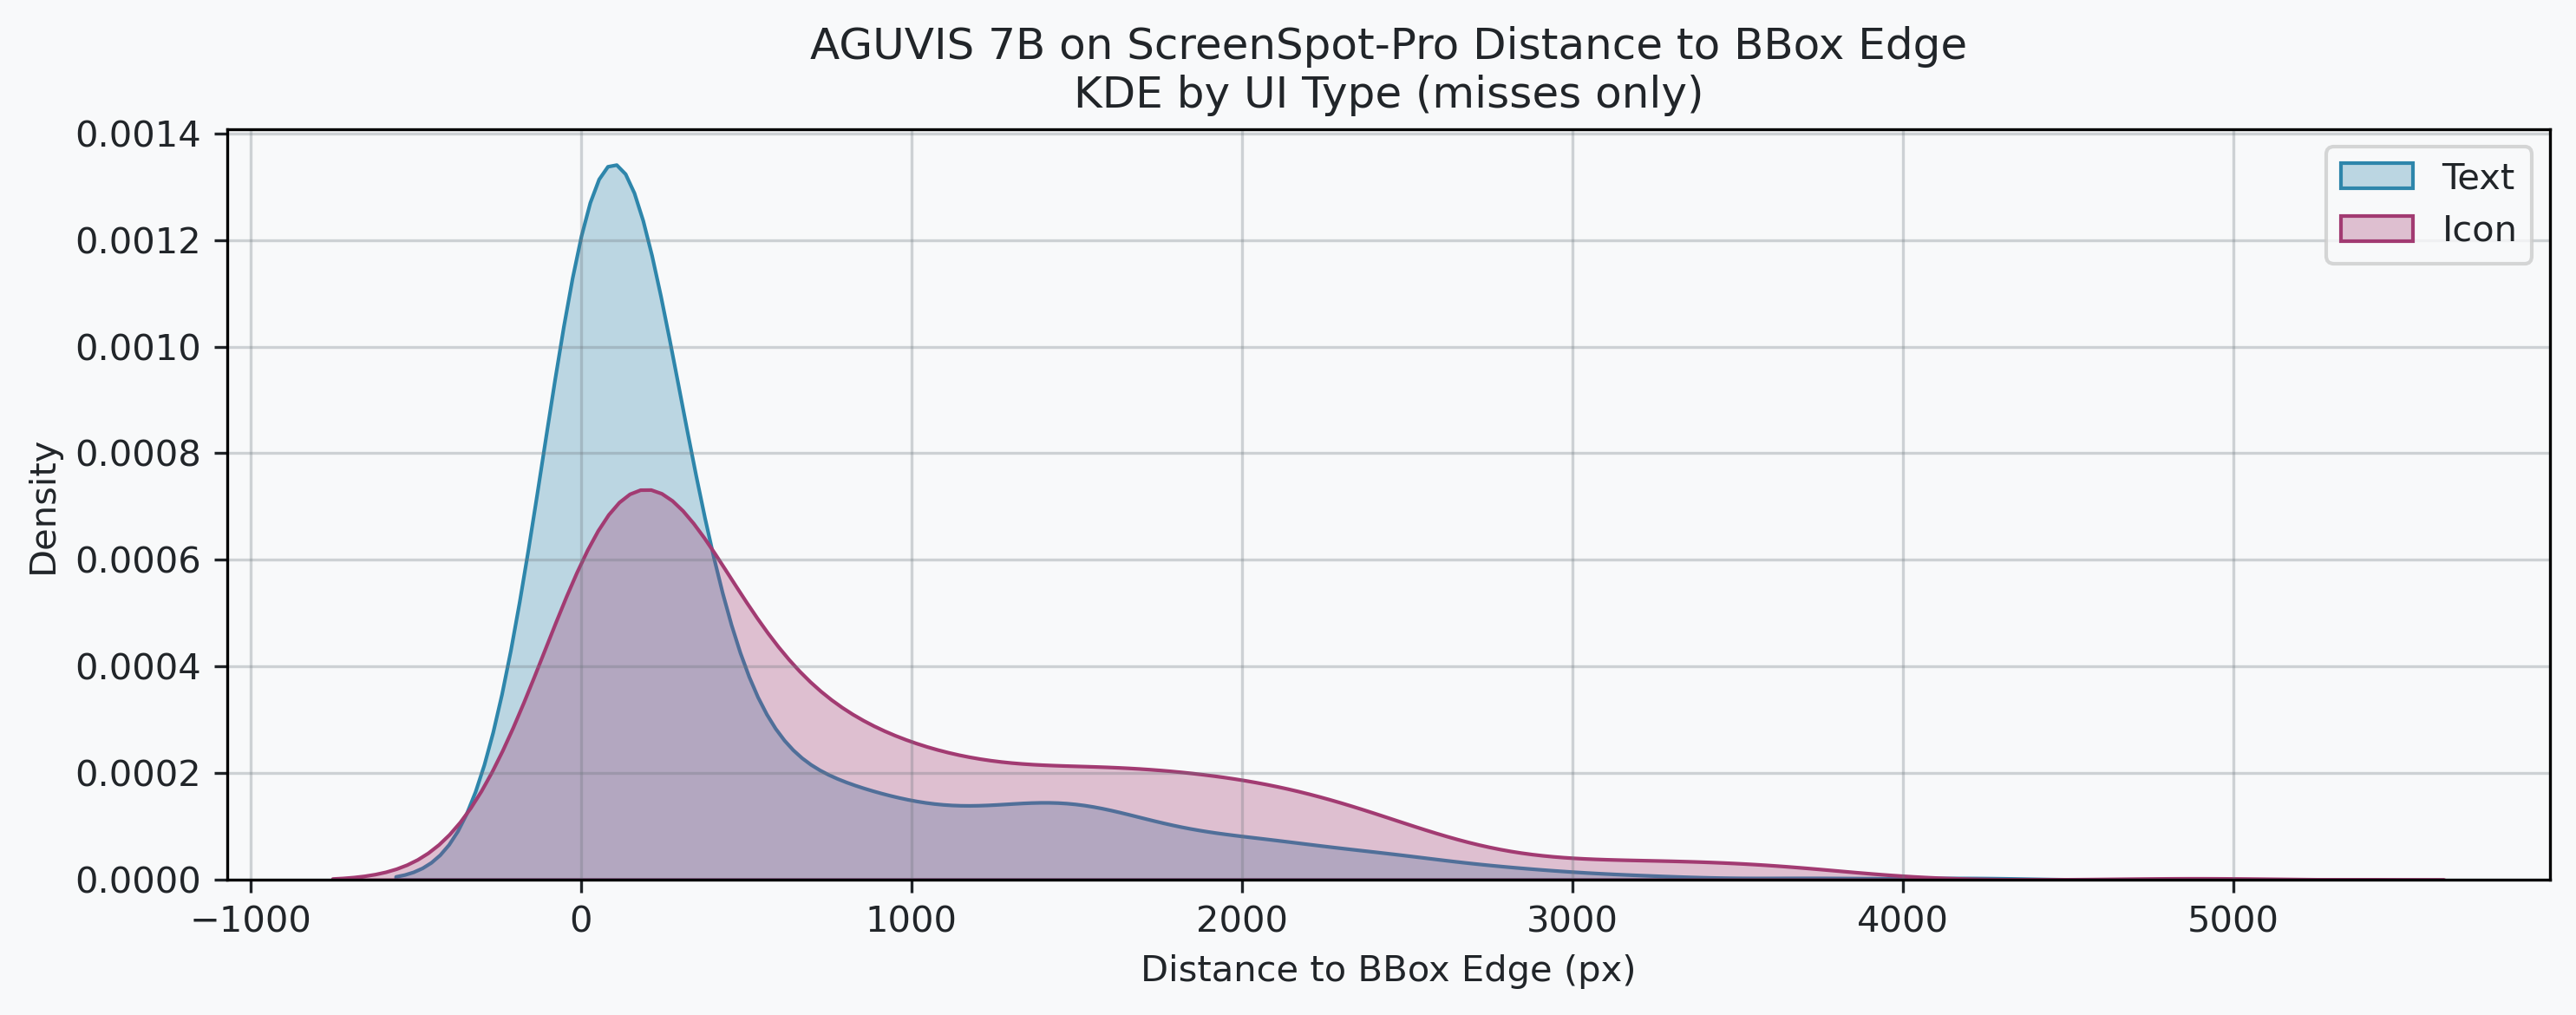

In [95]:
def plot_dist_to_edge_hist(df, figsize=(10, 4)):
    ui_colors = {"text": C2A_PALETTE["primary"], "icon": C2A_PALETTE["secondary"]}
    misses = df[~df['hit']]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, color in ui_colors.items():
        sns.kdeplot(
            misses[misses['ui_type'] == ui_type]['dist_to_edge'],
            ax=ax, color=color, label=ui_type.capitalize(), fill=True, alpha=0.3,
        )

    ax.set_xlabel("Distance to BBox Edge (px)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Density", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B on ScreenSpot-Pro Distance to BBox Edge\nKDE by UI Type (misses only)", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-to-edge-hist.png")
    plt.show()
    
plot_dist_to_edge_hist(results)

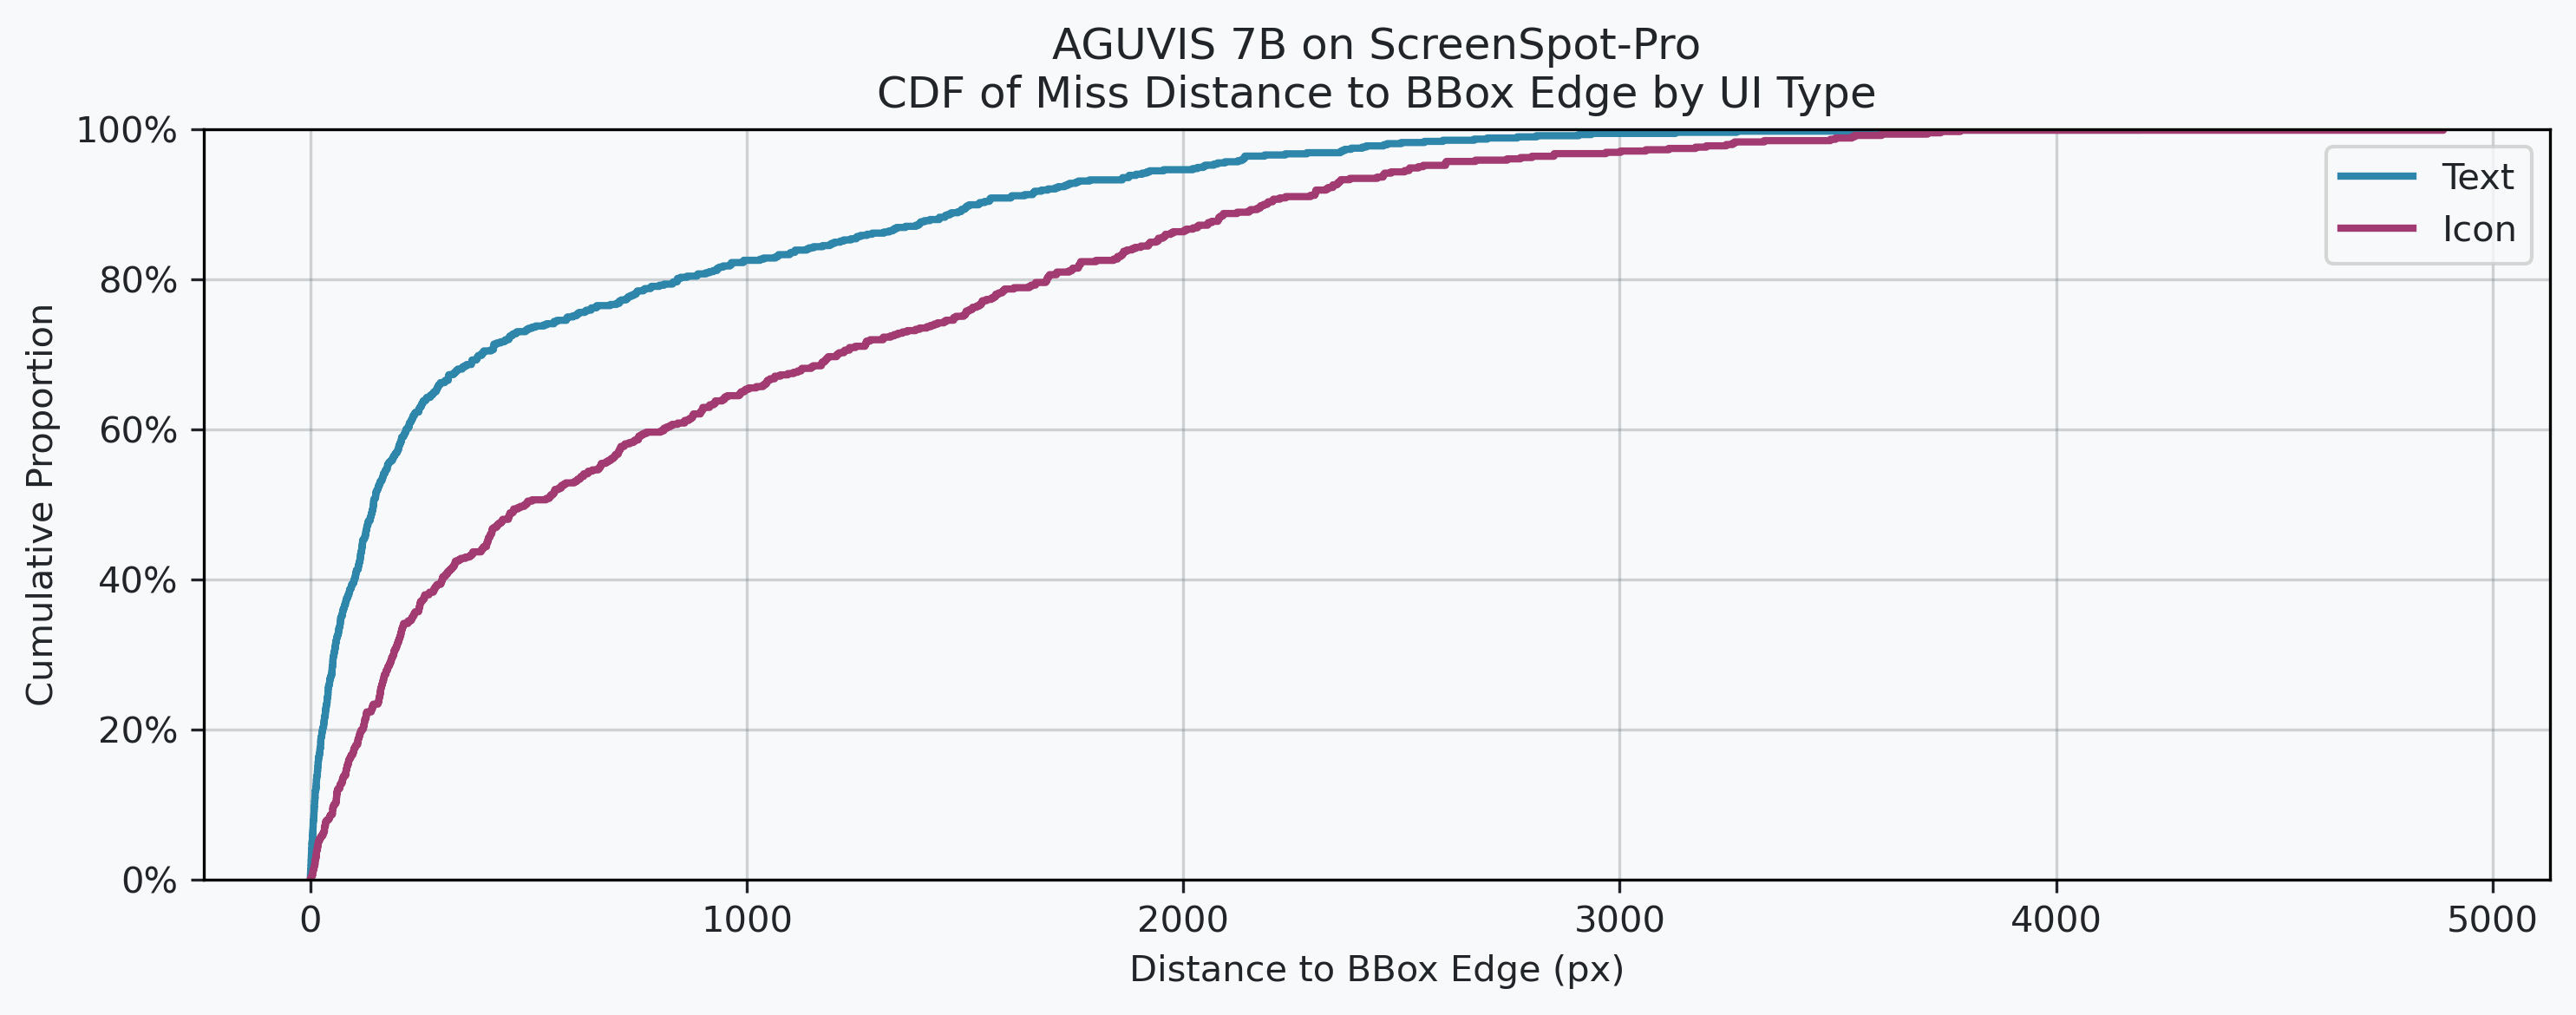

In [96]:
def plot_dist_to_edge_cdf(df, figsize=(10, 4)):
    ui_colors = {"text": C2A_PALETTE["primary"], "icon": C2A_PALETTE["secondary"]}
    misses = df[~df['hit']]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, color in ui_colors.items():
        sns.ecdfplot(
            misses[misses['ui_type'] == ui_type]['dist_to_edge'],
            ax=ax, color=color, label=ui_type.capitalize(), linewidth=2,
        )

    ax.set_xlabel("Distance to BBox Edge (px)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Cumulative Proportion", color=C2A_PALETTE["text"])
    ax.set_title("AGUVIS 7B on ScreenSpot-Pro\nCDF of Miss Distance to BBox Edge by UI Type", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-to-edge-cdf.png")
    plt.show()
    
plot_dist_to_edge_cdf(results)

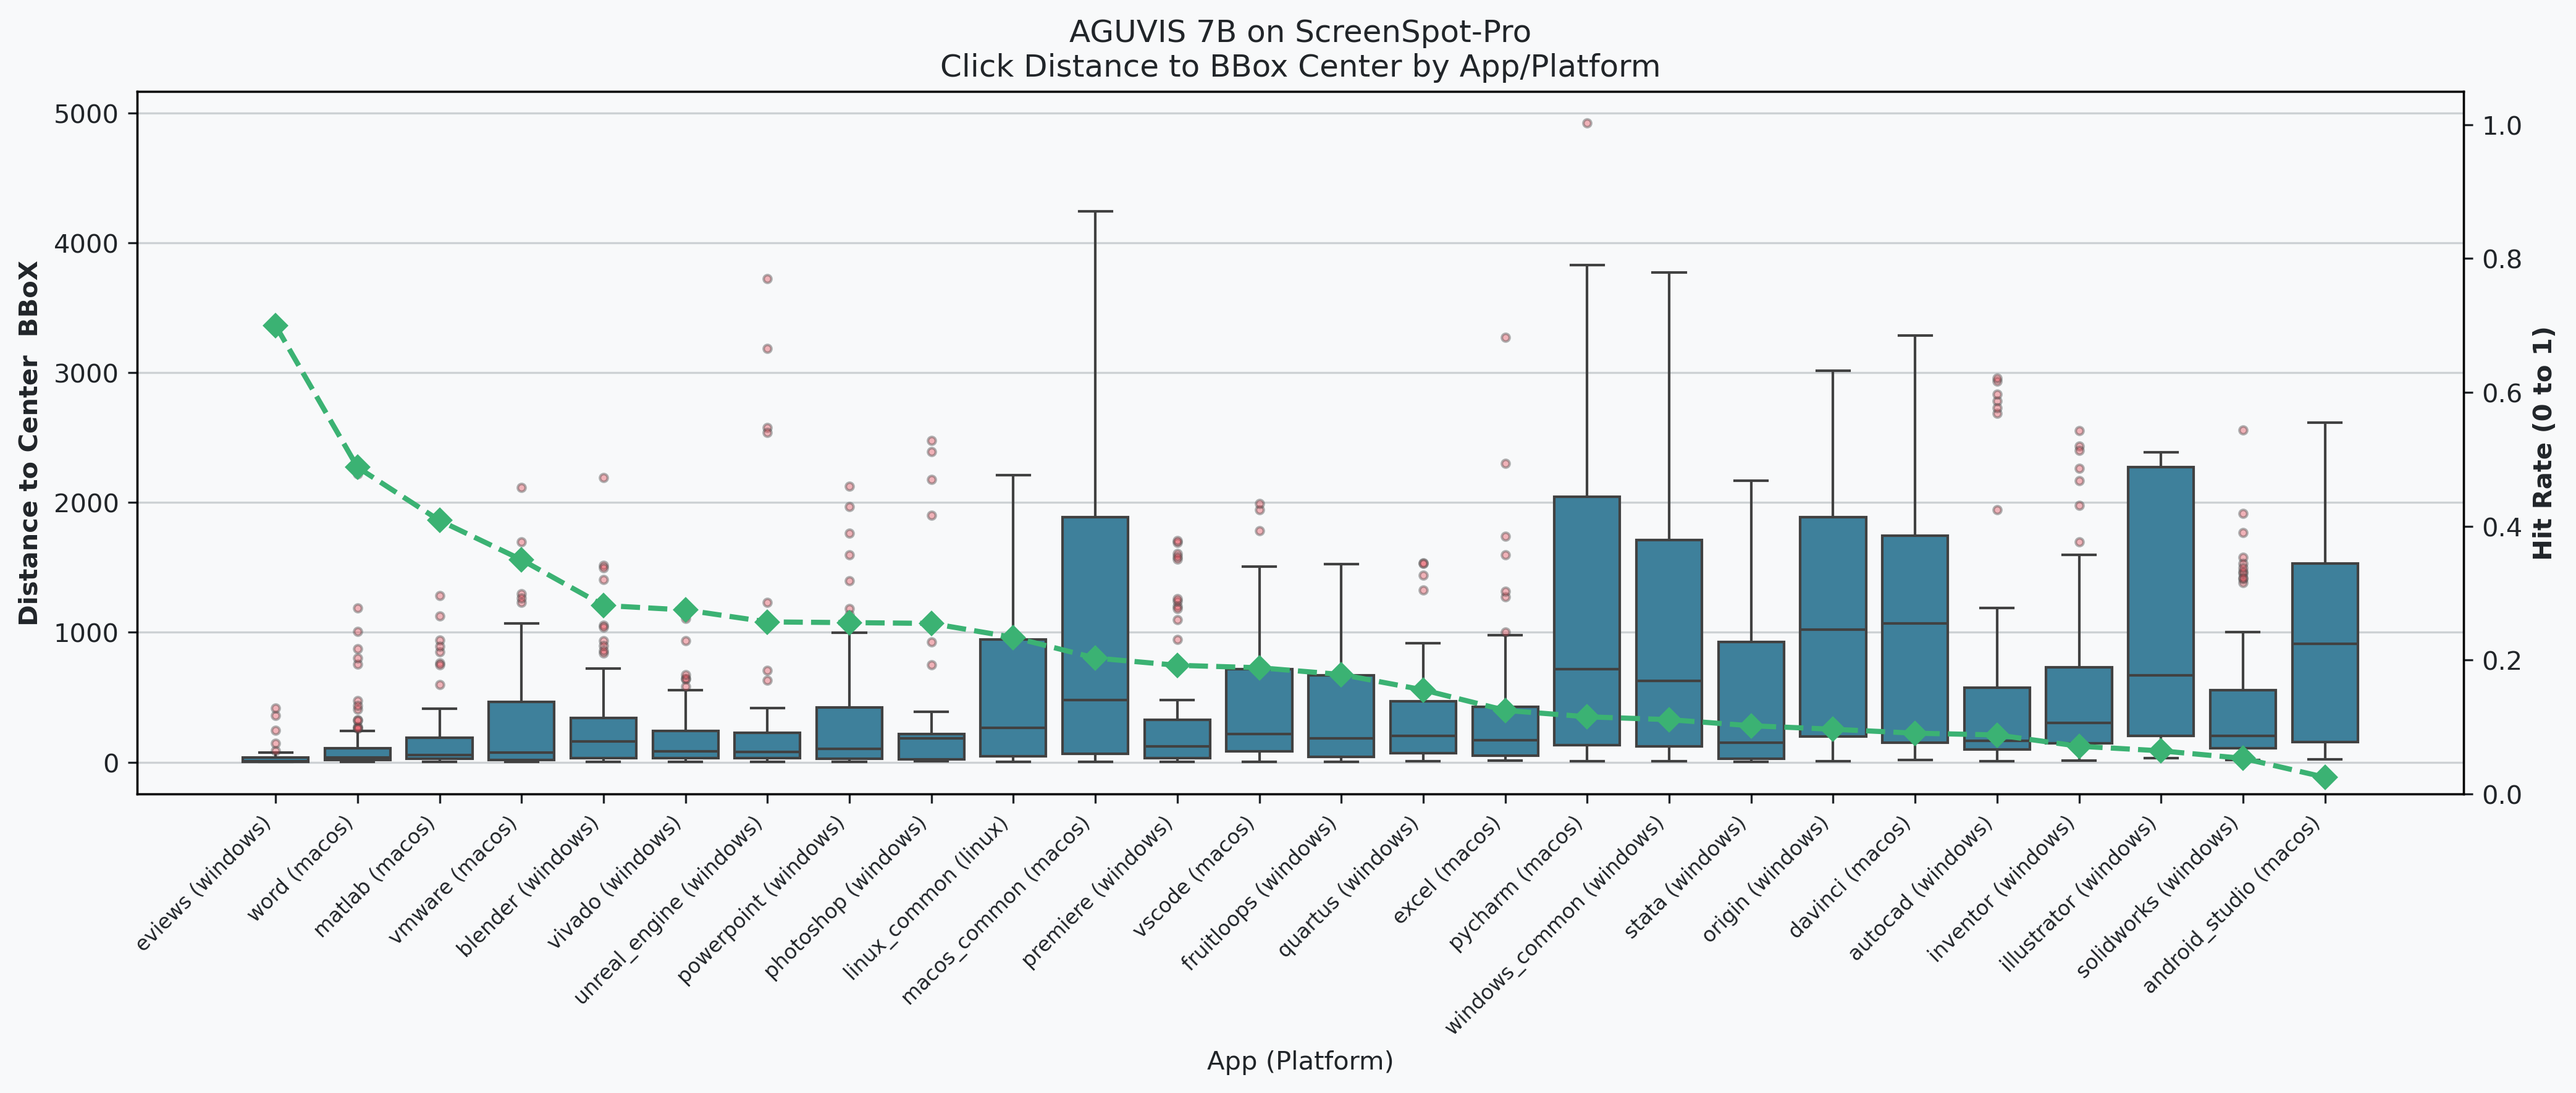

In [97]:
def plot_dist_center_by_app(df, figsize=(14, 6)):
    # 1. Calculate the hit rates and define the order
    hit_stats = df.groupby('app/platform')['hit'].mean().sort_values(ascending=False)
    order = hit_stats.index.tolist()
    hit_rates = hit_stats.values

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # 2. Draw the original boxplot on the primary (left) Y-axis
    sns.boxplot(
        data=df, x='app/platform', y='dist_to_center', order=order,
        color=C2A_PALETTE["primary"],
        flierprops=dict(marker='o', markerfacecolor=C2A_PALETTE["warning"], markersize=3, alpha=0.4),
        ax=ax,
    )

    ax.set_xlabel("App (Platform)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Distance to Center  BBoX", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_title("AGUVIS 7B on ScreenSpot-Pro\nClick Distance to BBox Center by App/Platform", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=C2A_PALETTE["text"], fontsize=8)
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)

    # ==========================================
    # 3. NEW: Add a secondary Y-axis for Hit Rate
    # ==========================================
    ax2 = ax.twinx()  # Create a second axes that shares the same x-axis
    
    # Use your secondary color if it exists, otherwise fallback to red or orange
    line_color = C2A_PALETTE["success"] 
    
    # Plot the line chart
    ax2.plot(
        range(len(order)), hit_rates, 
        color=C2A_PALETTE["success"], marker='D', markersize=6, linewidth=2, linestyle='--'
    )
    
    # Format the secondary axis
    ax2.set_ylabel("Hit Rate (0 to 1)", color=C2A_PALETTE["text"], fontweight='bold')
    ax2.set_ylim(0, 1.05)  # Force axis to go from 0 to slightly above 1 (100%)
    ax2.tick_params(axis='y', colors=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-center-by-app.png")
    plt.show()
    
plot_dist_center_by_app(results)

/tmp/ipykernel_1270820/3537639635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


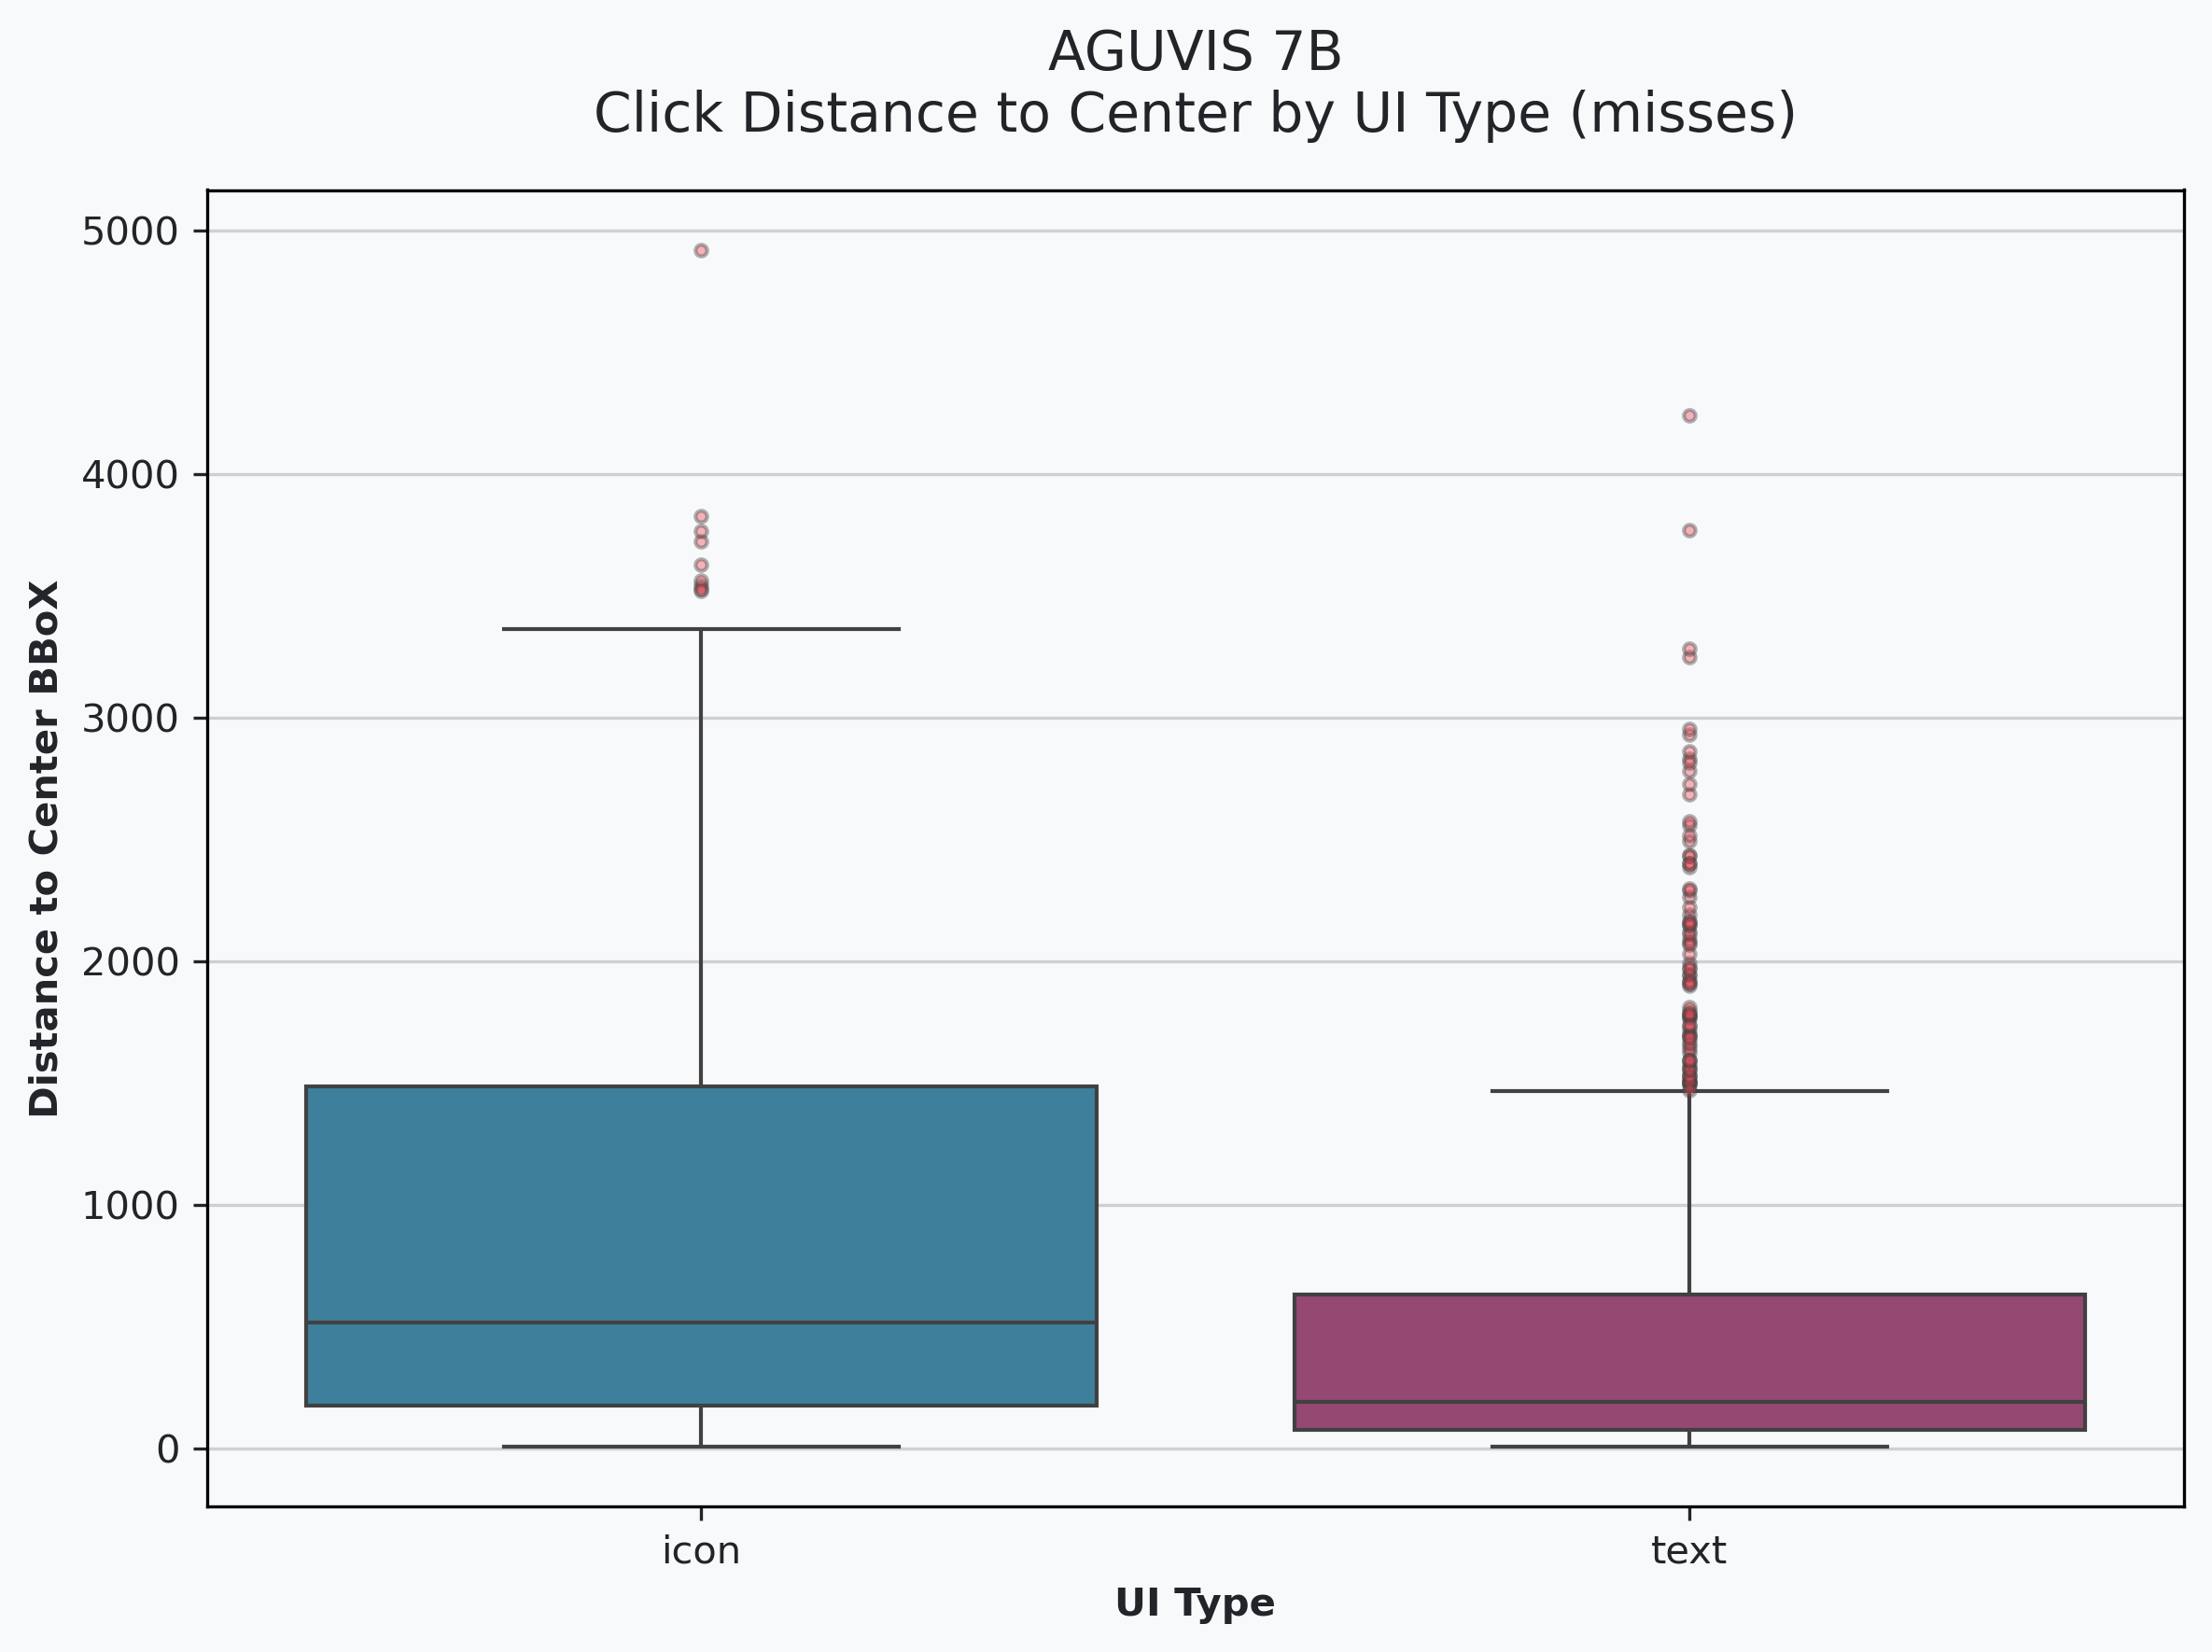

In [98]:
def plot_dist_center_by_ui_type(df, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    # Apply your custom background colors
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # Draw the boxplot. 
    # x='ui_type' automatically splits the data into separate boxes for Text and Icon.
    sns.boxplot(
        data=df[~df['hit']], 
        x='ui_type', 
        y='dist_to_center',
        palette=[C2A_PALETTE.get("primary", "#3498db"), C2A_PALETTE.get("secondary", "#9b59b6")],
        flierprops=dict(marker='o', markerfacecolor=C2A_PALETTE["warning"], markersize=3, alpha=0.4),
        ax=ax,
    )

    # Styling the labels and title
    ax.set_xlabel("UI Type", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_ylabel("Distance to Center BBoX", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_title("AGUVIS 7B\nClick Distance to Center by UI Type (misses)", color=C2A_PALETTE["text"], fontsize=14, pad=15)
    
    # Tick marks and grid
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-center-by-ui-type.png")
    plt.show()

# To run it:
plot_dist_center_by_ui_type(results)

/tmp/ipykernel_1270820/2579792759.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


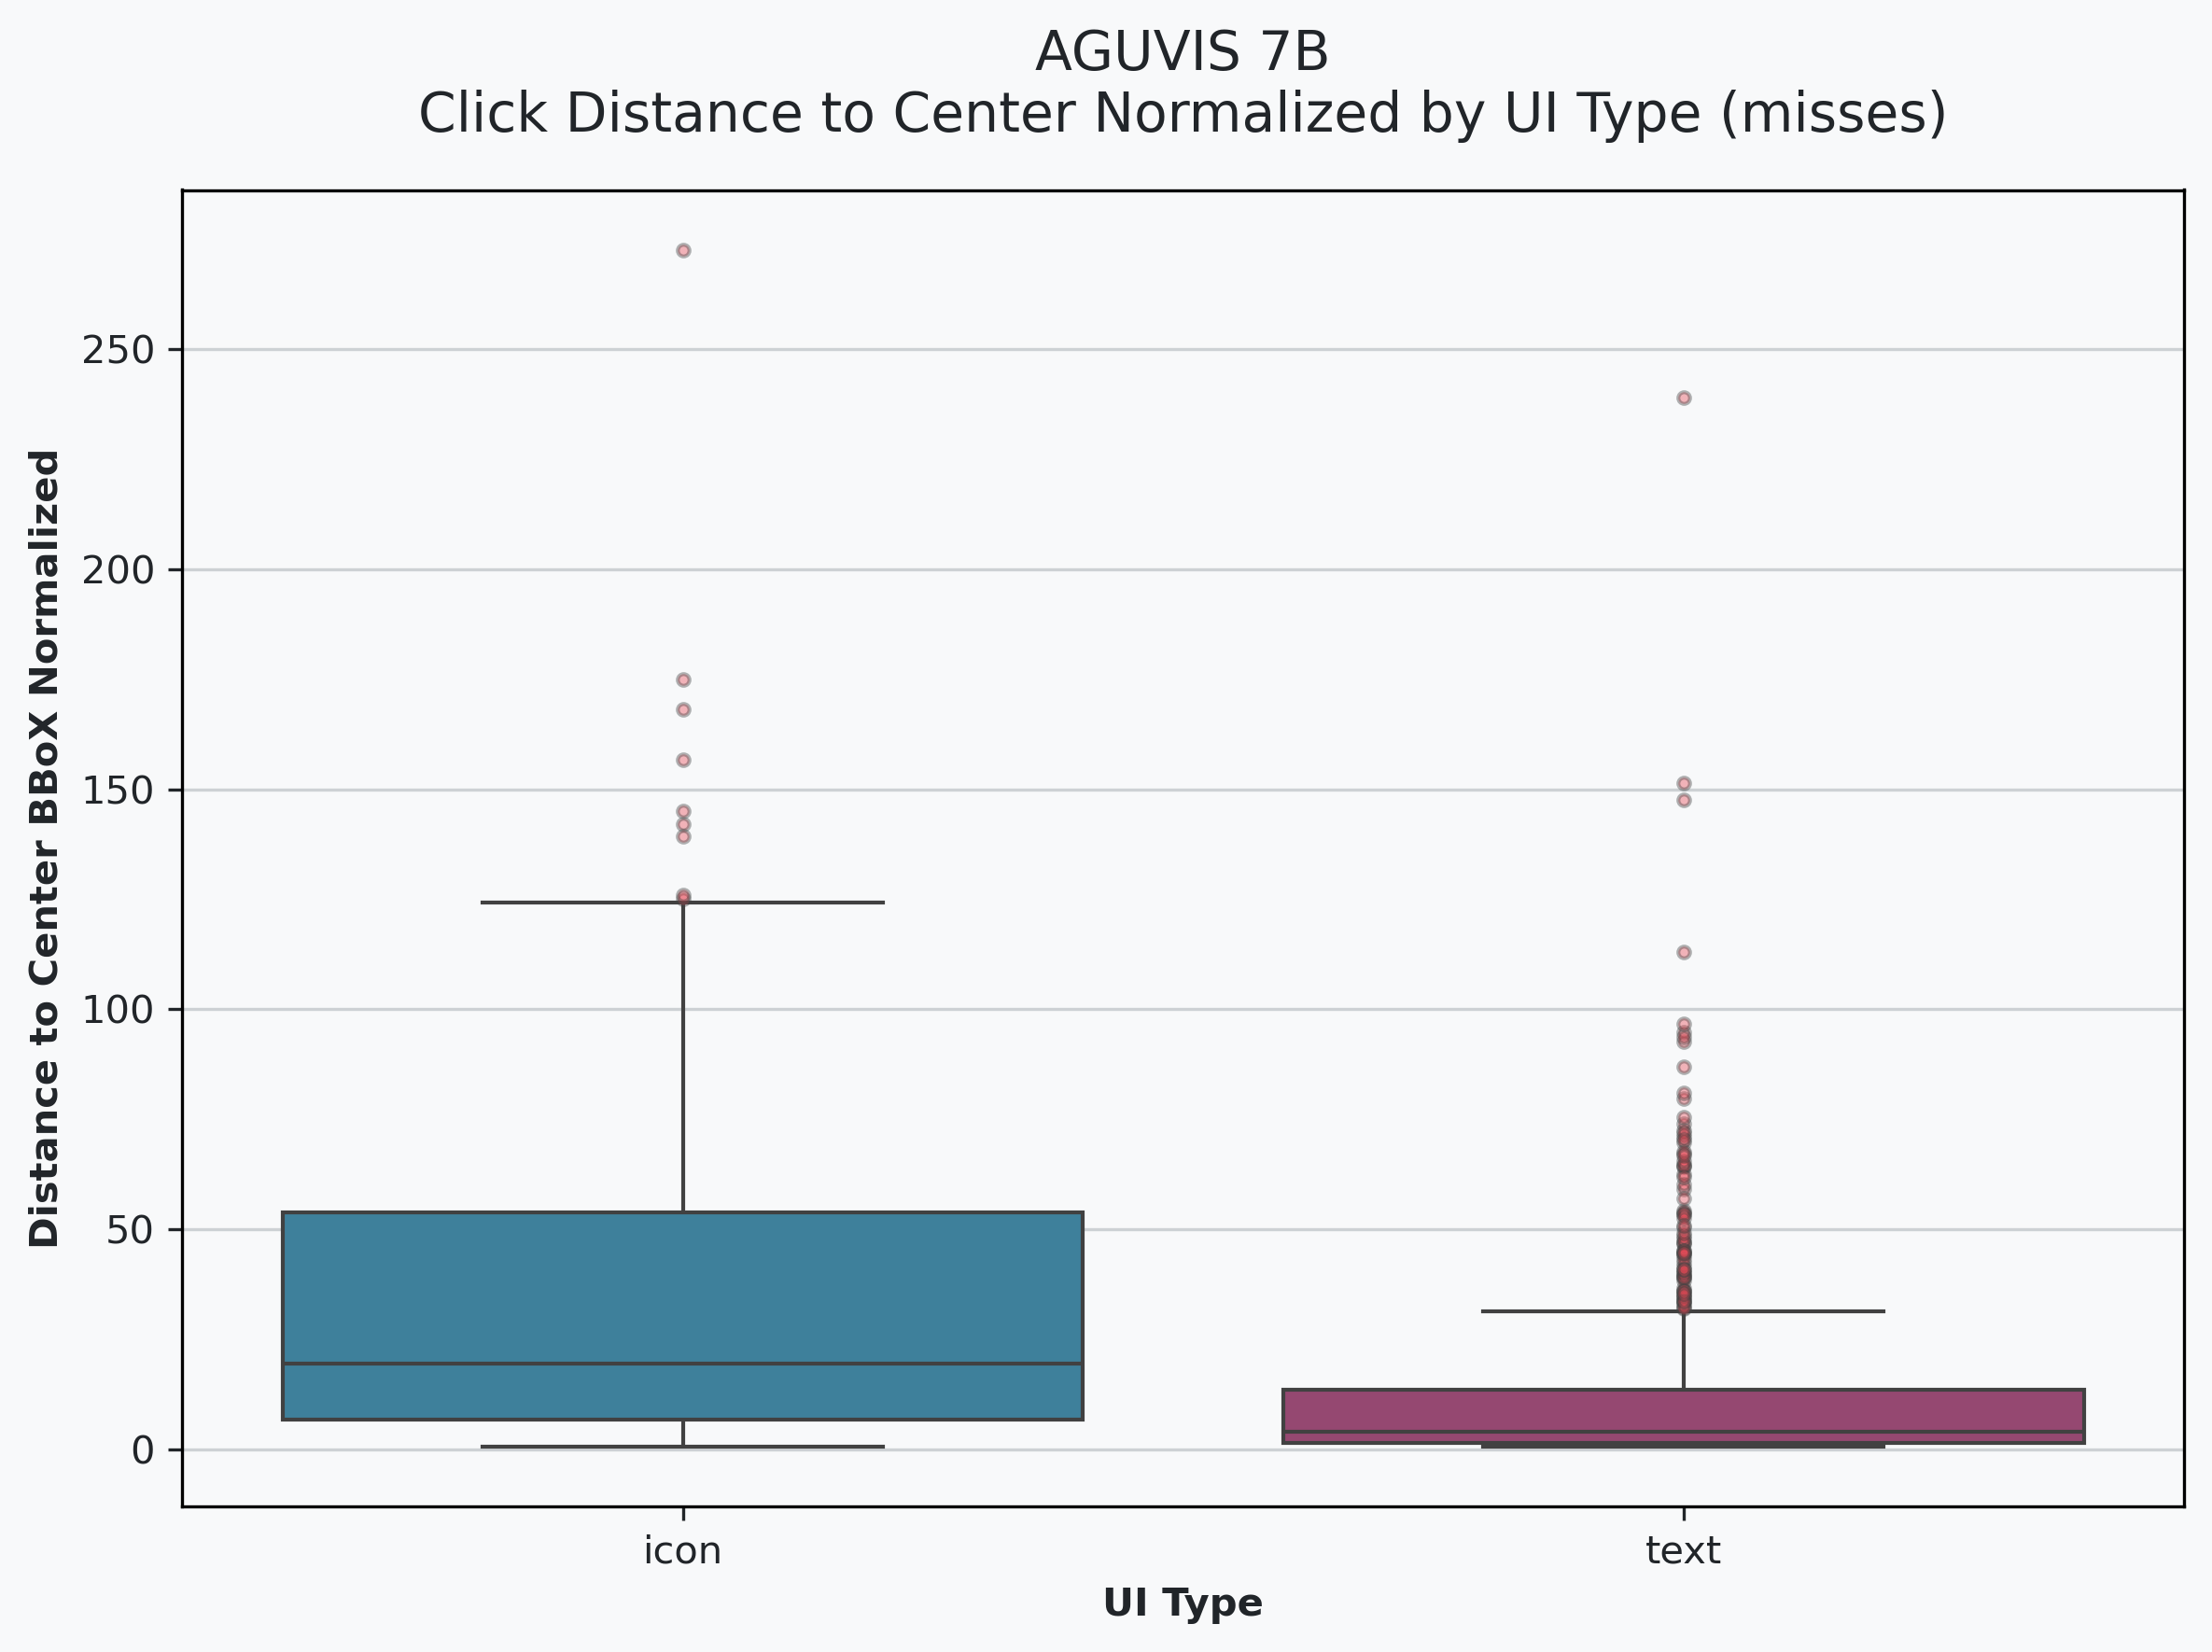

In [99]:
def plot_dist_center_by_ui_type(df, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    # Apply your custom background colors
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # Draw the boxplot. 
    # x='ui_type' automatically splits the data into separate boxes for Text and Icon.
    sns.boxplot(
        data=df[~df['hit']], 
        x='ui_type', 
        y='dist_to_center_norm',
        palette=[C2A_PALETTE.get("primary", "#3498db"), C2A_PALETTE.get("secondary", "#9b59b6")],
        flierprops=dict(marker='o', markerfacecolor=C2A_PALETTE["warning"], markersize=3, alpha=0.4),
        ax=ax,
    )

    # Styling the labels and title
    ax.set_xlabel("UI Type", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_ylabel("Distance to Center BBoX Normalized", color=C2A_PALETTE["text"], fontweight='bold')
    ax.set_title("AGUVIS 7B\nClick Distance to Center Normalized by UI Type (misses)", color=C2A_PALETTE["text"], fontsize=14, pad=15)
    
    # Tick marks and grid
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)

    plt.tight_layout()
    plt.savefig("./results/aguvis-dist-center-norm-by-ui-type.png")
    plt.show()

# To run it:
plot_dist_center_by_ui_type(results)